# QA · ¿Qué tan cerca está nuestra metodología de la línea base de Nielsen? — Bepensa · ZM Mérida · sueros

**Línea base:** `qa/Golden Stores Sueros R.Sur - KO FY'23.xlsx` (NielsenIQ, Golden Stores de sueros FY'23, Región Sur,
**canal Autoservicios**: Bodega Aurrera, Chedraui, Walmart, Soriana, San Francisco de Asís…). Por tienda trae su clúster HH/HL/LH/LL,
el semáforo, las coordenadas y el perfil de hogares de su área (tamaño, niños, edad del jefe y NSE: HHs · % · índice).

**Nuestro modelo:** las letras del notebook 06 (`data/processed/merida/bepensa/letras_pdv_bepensa_zm_merida.parquet`) para los PDV
**Tradicional** del CP de Bepensa, y los hogares por hexágono del 04 (INEGI, reparto por área de manzana, 2025).

**El problema de fondo:** Nielsen es canal **Moderno** y nuestras letras son del canal **Tradicional**: no hay una sola tienda en
común (no hay llave, son otros establecimientos). Por eso el QA mide la cercanía en tres niveles, del más directo al más lejano:

| Nivel | Qué se compara | ¿Depende del canal? |
|---|---|---|
| A · Insumos | el perfil de hogares que calculamos **en la coordenada de cada supermercado** contra el que reporta Nielsen | no: es la zona |
| B · Método | nuestra regla de Letra 1 aplicada **en la coordenada del supermercado** contra la 1.ª letra de Nielsen | no: es la zona |
| C · Geografía | las letras de **nuestras tiendas Tradicional alrededor** del supermercado contra las letras de Nielsen | Letra 1 no; Letra 2 sí |

Más dos piezas: **0** (cuánto mueven AltScore y Rappi nuestras letras, el análisis original de este QA) y **D** (si Rappi, que sí
observa supermercados, anticipa la 2.ª letra de Nielsen). Al final, una **tarjeta de resultados** y los límites.

**Reproducir:** desde la raíz del repo, `uv run python src/py2nb.py qa/_src/qa_linea_base_nielsen.py qa/qa_linea_base_nielsen.ipynb`
y correr el notebook (kernel del repo). Lee los intermedios de `data/processed/merida/bepensa/` (correr antes 00 → 06).

In [1]:
import os
import sys
import hashlib
from pathlib import Path

os.environ.setdefault("CIUDAD", "merida")
BASE = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
sys.path.insert(0, str(BASE / "src"))

import numpy as np
import pandas as pd
import geopandas as gpd
import h3
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import roc_auc_score, roc_curve
from IPython.display import display

import config as C
import altscore as A
import eda
import letras as LT
import mapas as MP
import rappi as R

eda.estilo()
pd.set_option("display.width", 220, "display.max_columns", 40, "display.float_format", "{:,.3f}".format)
QA = BASE / "qa"
OUT = QA / "salidas"
OUT.mkdir(exist_ok=True)
F_NIELSEN = QA / "Golden Stores Sueros R.Sur - KO FY'23.xlsx"
F_LETRAS = C.PROC / f"letras_pdv_{C.CLIENTE}_{C.SLUG}.parquet"
F_HEX = C.PROC / f"hexagonos_h3r{C.H3_RES}_{C.CLIENTE}_{C.SLUG}.gpkg"
F_AGEB = C.PROC / f"ageb_{C.SLUG}.gpkg"
F_RAPPI = C.PROC / f"rappi_hidratacion_tiendas_{C.SLUG}.parquet"
F_ALT = C.PROC / f"altscore_{C.CLIENTE}_{C.SLUG}.parquet"
F_PDV = C.PROC / f"pdv_{C.CLIENTE}_hexagonos_{C.SLUG}.pkl"
for f_ in [F_NIELSEN, F_LETRAS, F_HEX, F_AGEB, F_RAPPI, F_PDV]:
    assert f_.exists(), f"Falta {f_.relative_to(BASE)}: correr el pipeline 00 → 06 (o copiar la línea base de Nielsen a qa/)"
R300, RES_CL, LAM, MIN_ALT = C.RADIO_PDV_M, C.NSE_CLUSTER_RES, C.ALTSCORE_PESO_NSE, C.ALTSCORE_MIN_PUNTOS
NSE = ["A/B", "C+", "C", "C-", "D+", "D/E"]
K_NSE = pd.Series({"A/B": 6, "C+": 5, "C": 4, "C-": 3, "D+": 2, "D/E": 1})      # mismo orden que letras.NIVELES (1 = D/E … 6 = A/B)
GRUPOS = {"Tamaño del hogar": ["2 o Menos Personas", "3 personas", "4 personas", "5 personas", "6+ personas"],
          "Presencia de niños": ["Niño < 6", "Niño 6 - 11", "Niño 12+", "Sin Niños"],
          "Edad del jefe": ["Edad menos de 35", "Edad 35 - 44", "Edad 45 - 54", "Edad 55 - 64", "Edad 65+"],
          "NSE AMAI": NSE}
RNG = np.random.default_rng(eda.SEMILLA)


def sha(p):
    return hashlib.sha256(Path(p).read_bytes()).hexdigest()


def boot(fn, *arrs, B=2000):
    """IC95 por bootstrap de tiendas (remuestreo con reemplazo de las filas, semilla fija)."""
    n = len(arrs[0])
    vals = []
    for _ in range(B):
        i = RNG.integers(0, n, n)
        try:
            vals.append(fn(*[np.asarray(a)[i] for a in arrs]))
        except ValueError:
            continue
    return np.nanpercentile(vals, [2.5, 97.5])


def kappa(a, b):
    return eda.kappa_cohen(pd.Series(a), pd.Series(b))


def acuerdo(nombre, ref, pred):
    """Fila de concordancia: exactitud, κ de Cohen y sus IC95 por bootstrap."""
    ref, pred = np.asarray(ref, object), np.asarray(pred, object)
    acc = (ref == pred).mean()
    lo_a, hi_a = boot(lambda r, p: (r == p).mean(), ref, pred)
    k = kappa(ref, pred)
    lo_k, hi_k = boot(lambda r, p: kappa(r, p), ref, pred)
    return {"comparación": nombre, "n": len(ref), "exactitud": acc, "IC95 exactitud": f"[{lo_a:.2f}, {hi_a:.2f}]",
            "κ de Cohen": k, "IC95 κ": f"[{lo_k:.2f}, {hi_k:.2f}]",
            "lectura κ": pd.cut([k], [-1, 0.2, 0.4, 0.6, 0.8, 1.01], labels=["pobre", "regular", "moderado", "bueno", "casi perfecto"])[0]}


print(f"{C.ZM_NOMBRE} · línea base: {F_NIELSEN.name} · nuestro modelo: {F_LETRAS.name} · radio {R300} m · clúster NSE H3 res {RES_CL}")

ZM Mérida · línea base: Golden Stores Sueros R.Sur - KO FY'23.xlsx · nuestro modelo: letras_pdv_bepensa_zm_merida.parquet · radio 300 m · clúster NSE H3 res 9


## 0. Datos y procedencia

**Qué se hace:** se lee la línea base (encabezado de 2 niveles: categoría y HHs · % · Índice) y se guarda la huella SHA-256 de
cada archivo que entra al QA. Se recorta la línea base a la **ZM Mérida** (columna `Zonas Metropolitanas` = MERIDA), que es donde
tenemos hogares por hexágono y letras.

**Por qué:** el QA debe poder repetirse con exactamente los mismos archivos; si cambia uno, cambia la huella.

In [2]:
raw = pd.read_excel(F_NIELSEN, sheet_name=0, header=None)
h1, h2 = raw.iloc[7].ffill(), raw.iloc[8]
cols = [f"{' '.join(str(a).split())}|{b}" if pd.notna(a) and b in ("HHs", "%", "Indice") else str(b).strip() for a, b in zip(h1, h2)]
nie = raw.iloc[9:].copy()
nie.columns = cols
nie = nie[nie["Nielsen ID"].notna()].reset_index(drop=True)
nie["lat"], nie["lon"] = nie.Latitud.astype(float), nie.Longitud.astype(float)
nie["cluster_n"] = nie["Cluster"].astype(str).str.strip()
nie["L1n"], nie["L2n"] = nie.cluster_n.str[0], nie.cluster_n.str[1]
CATS = [c for g in GRUPOS.values() for c in g]
for c in CATS:
    for s_ in ("HHs", "%", "Indice"):
        nie[f"{c}|{s_}"] = pd.to_numeric(nie[f"{c}|{s_}"], errors="coerce")
pn_all = nie[[f"{c}|%" for c in NSE]].set_axis(NSE, axis=1)
nie["N_n"] = (pn_all * K_NSE).sum(axis=1) / pn_all.sum(axis=1)     # nivel NSE medio de Nielsen, misma escala 1-6 que la nuestra
nie["HH_n"] = nie[[f"{c}|HHs" for c in NSE]].sum(axis=1)
zm = nie[nie["Zonas Metropolitanas"].eq("MERIDA")].reset_index(drop=True)

let = pd.read_parquet(F_LETRAS)
pdv = pd.read_pickle(F_PDV)[""][["pos_id_cp", "Latitud", "Longitud"]]
let = let.merge(pdv, on="pos_id_cp", how="left")
hexg = gpd.read_file(F_HEX).set_index("hex")
ageb = gpd.read_file(F_AGEB)
rp = pd.read_parquet(F_RAPPI)

fuentes_qa = pd.DataFrame([{"archivo": str(p.relative_to(BASE)), "bytes": p.stat().st_size, "sha256": sha(p)}
                           for p in [F_NIELSEN, F_LETRAS, F_HEX, F_AGEB, F_RAPPI, F_PDV]])
display(fuentes_qa)
COBERTURA = (f"Línea base: {len(nie):,} autoservicios de la Región Sur ({nie['Región Nielsen'].nunique()} áreas Nielsen, "
             f"{nie.Estado.nunique()} estados); {len(zm)} en la ZM Mérida ({', '.join(f'{k} {v}' for k, v in zm.Municipio.value_counts().items())}). "
             f"Clústeres en la ZM: " + " · ".join(f"{k} {v}" for k, v in zm.cluster_n.value_counts().items()) +
             f". Nuestro modelo: {int(let.objetivo.sum()):,} PDV Tradicional objetivo con letras.")
print(COBERTURA)
display(zm["Cadena de Autoservicios"].value_counts().rename("tiendas en la ZM").to_frame())

,archivo,bytes,sha256
0,qa\Golden Stores Sueros R.Sur - KO FY'23.xlsx,1013212,9d181d21bfd581390fc9dd49c6e9a5a610cf4c276d3b06...
1,data\processed\merida\bepensa\letras_pdv_bepen...,951088,48b2c20c2488bafc143cf7bcf418a1119911b98787a174...
2,data\processed\merida\bepensa\hexagonos_h3r10_...,17186816,71d572d3bf6d2d6d5724f2ad7a21564f7d812c869ebe51...
3,data\processed\merida\bepensa\ageb_zm_merida.gpkg,1331200,5e1a125321de07b76d18c1a957441823d55d6f7592cd17...
4,data\processed\merida\bepensa\rappi_hidratacio...,46449,b94278c1faf8261984a9cb0bee11f0330eecd3835768a9...
5,data\processed\merida\bepensa\pdv_bepensa_hexa...,7428142,afd2c9cbb69fdff25fceb03f5d7e48e4a4f4c4f3fd7128...


Línea base: 1,420 autoservicios de la Región Sur (3 áreas Nielsen, 15 estados); 65 en la ZM Mérida (Mérida (YUC) 62, Umán (YUC) 2, Kanasín (YUC) 1). Clústeres en la ZM: HL 33 · LL 17 · HH 12 · LH 3. Nuestro modelo: 5,566 PDV Tradicional objetivo con letras.


,tiendas en la ZM
Cadena de Autoservicios,
SUPER SAN FCO DE ASIS,23
BODEGA AURRERA,9
WAL-MART,7
CHEDRAUI,6
SORIANA SUPER,6
SORIANA HIPER,5
MI BODEGA,4
CHEDRAUI SELECTO,2
WALMART EXPRESS,2


## 0b. Cuánto mueven AltScore y Rappi nuestras letras (consistencia interna)

**Qué se hace:** el análisis original de este QA, corregido de nombre: compara las **letras base** (solo INEGI + CP) con las
**finales** (Letra 1 con AltScore, Letra 2 con Rappi) en los PDV objetivo. Se lee directo del parquet del 06 (no de una copia
del Excel, que puede quedar vieja).

**Por qué:** esto **no es exactitud**: base y final salen del mismo modelo. Mide cuánto cambian las fuentes adicionales; la
exactitud contra una referencia externa es la de las secciones A-D.

In [3]:
ob = let[let.objetivo].copy()
interno = pd.DataFrame([acuerdo("Letras base → finales", ob.letras_base, ob.letras),
                        acuerdo("Letra 1 sin → con AltScore", ob.L1_sin_alt, ob.L1),
                        acuerdo("Letra 2 sin → con Rappi", ob.L2_sin_rappi, ob.L2)])
display(interno)
display(pd.crosstab(ob.letras_base.rename("base (INEGI + CP)"), ob.letras.rename("final (AltScore + Rappi)"), margins=True))

,comparación,n,exactitud,IC95 exactitud,κ de Cohen,IC95 κ,lectura κ
0,Letras base → finales,5566,0.881,"[0.87, 0.89]",0.833,"[0.82, 0.84]",casi perfecto
1,Letra 1 sin → con AltScore,5566,0.920,"[0.91, 0.93]",0.839,"[0.82, 0.85]",casi perfecto
2,Letra 2 sin → con Rappi,5566,0.959,"[0.95, 0.96]",0.903,"[0.89, 0.92]",casi perfecto


final (AltScore + Rappi),HH,HL,LH,LL,All
base (INEGI + CP),,,,,
HH,685,76,39,4,804
HL,23,1606,0,105,1734
LH,76,8,777,97,958
LL,2,213,18,1837,2070
All,786,1903,834,2043,5566


## A. Insumos: ¿el perfil de hogares que calculamos coincide con el de Nielsen en la misma coordenada?

**Qué se hace:** en la coordenada de cada autoservicio de la ZM se suman nuestros hogares por hexágono H3 res 10 (los mismos del
04: Censo 2020 por manzana repartido por área, rurales y crecimiento a 2025) dentro de varios radios (300 m a 3 km), y se
comparan con los de Nielsen: (1) el **número de hogares** (ρ de Spearman y cociente nuestro / Nielsen); (2) la **distribución**
de cada grupo (tamaño, niños, edad del jefe, NSE): error absoluto medio en puntos porcentuales y ρ por categoría; (3) el
**nivel NSE medio** N = Σ k·p_k y el % ABC+ (A/B + C+), que son lo que decide la 1.ª letra.

**Por qué:** si nuestros insumos no reproducen el perfil de Nielsen en el mismo punto, ninguna regla los va a acercar. Se prueban
varios radios porque Nielsen no publica el área que usó.

In [4]:
RADIOS = [300, 500, 800, 1000, 1500, 2000, 3000]
hh_cols = {c: f"HHs_{c}" for c in CATS}
hx_cat = hexg[list(hh_cols.values())].set_axis(CATS, axis=1)
nuestro = {}
for r_ in RADIOS:
    s_ = LT.suma_area(hx_cat, LT.hexagonos_en_radio(zm.lat, zm.lon, r_, C.H3_RES)).set_axis(CATS, axis=1)
    nuestro[r_] = s_
filas_r = []
for r_, s_ in nuestro.items():
    tot = s_[NSE].sum(axis=1)
    p_ = s_[NSE].div(tot.replace(0, np.nan), axis=0)
    N_ = (p_ * K_NSE).sum(axis=1)
    abc_ = (p_["A/B"] + p_["C+"]) * 100
    fila = {"radio (m)": r_, "hogares nuestros (mediana)": tot.median(), "hogares Nielsen (mediana)": zm.HH_n.median(),
            "cociente nuestro / Nielsen (mediana)": (tot / zm.HH_n).median(), "ρ hogares": stats.spearmanr(tot, zm.HH_n)[0],
            "ρ nivel NSE (N)": stats.spearmanr(N_, zm.N_n, nan_policy="omit")[0],
            "ρ % ABC+": stats.spearmanr(abc_, (zm["A/B|%"] + zm["C+|%"]) * 100, nan_policy="omit")[0]}
    for g_, cs in GRUPOS.items():
        pg = s_[cs].div(s_[cs].sum(axis=1).replace(0, np.nan), axis=0)
        png_ = zm[[f"{c}|%" for c in cs]].set_axis(cs, axis=1)
        png_ = png_.div(png_.sum(axis=1), axis=0)
        fila[f"error medio {g_} (pp)"] = (pg - png_).abs().mean().mean() * 100
    filas_r.append(fila)
radios = pd.DataFrame(filas_r)
display(radios.round(3))
R_MEJOR = int(radios.loc[radios["ρ nivel NSE (N)"].idxmax(), "radio (m)"])
print(f"Radio con el perfil NSE más parecido: {R_MEJOR} m. En nuestro radio de trabajo ({R300} m): ρ(N) = "
      f"{radios.set_index('radio (m)').loc[R300, 'ρ nivel NSE (N)']:.2f}, error NSE {radios.set_index('radio (m)').loc[R300, 'error medio NSE AMAI (pp)']:.1f} pp.")

,radio (m),hogares nuestros (mediana),hogares Nielsen (mediana),cociente nuestro / Nielsen (mediana),ρ hogares,ρ nivel NSE (N),ρ % ABC+,error medio Tamaño del hogar (pp),error medio Presencia de niños (pp),error medio Edad del jefe (pp),error medio NSE AMAI (pp)
0,300,278.533,"2,494.000",0.092,-0.263,0.898,0.902,4.954,11.373,6.317,2.861
1,500,983.474,"2,494.000",0.331,-0.239,0.919,0.924,4.880,11.315,6.112,2.542
2,800,"2,796.532","2,494.000",0.942,-0.110,0.927,0.926,4.741,11.166,5.839,2.374
3,1000,"4,413.327","2,494.000",1.432,-0.062,0.932,0.932,4.694,11.103,5.641,2.369
4,1500,"9,306.920","2,494.000",3.142,0.075,0.948,0.949,4.554,11.003,5.345,2.168
5,2000,"16,800.262","2,494.000",5.559,0.139,0.928,0.944,4.447,10.919,5.063,2.110
6,3000,"35,481.434","2,494.000",13.432,0.071,0.914,0.929,4.312,10.801,4.507,2.151


Radio con el perfil NSE más parecido: 1500 m. En nuestro radio de trabajo (300 m): ρ(N) = 0.90, error NSE 2.9 pp.


### A.1 El número de hogares no se reproduce con ningún radio: Nielsen usa otra área

**Qué se hace:** se prueba también la **AGEB que contiene a la tienda** (el formato de Nielsen es el de nuestro entregable por
AGEB) y se mira el número de hogares de Nielsen por cadena.

**Por qué:** si el área de Nielsen fuera un círculo fijo o la AGEB, algún radio daría ρ alto en hogares; si cambia por formato de
tienda (un hipermercado atrae de más lejos que un súper de barrio), el número de hogares no es comparable pero el **perfil** sí.

In [5]:
pts_zm = gpd.GeoDataFrame(zm[["Nielsen ID"]], geometry=gpd.points_from_xy(zm.lon, zm.lat), crs=4326).to_crs(ageb.crs)
j_ = gpd.sjoin(pts_zm, ageb[["CVEGEO", "Total HHs", "geometry"]], how="left", predicate="within")
j_ = j_[~j_.index.duplicated()]
zm["HH_ageb"] = j_["Total HHs"].reindex(zm.index).to_numpy()
RHO_AGEB = stats.spearmanr(zm.HH_ageb, zm.HH_n, nan_policy="omit")[0]
por_cadena = zm.groupby("Cadena de Autoservicios").agg(tiendas=("HH_n", "size"), **{"hogares Nielsen (mediana)": ("HH_n", "median")},
                                                      **{"hogares 1 km nuestros (mediana)": ("Nielsen ID", lambda s: nuestro[1000].loc[s.index, NSE].sum(axis=1).median())})
display(por_cadena.sort_values("hogares Nielsen (mediana)", ascending=False).round(0))
HOGARES = (f"Número de hogares: ningún radio lo reproduce (ρ entre {radios['ρ hogares'].min():+.2f} y {radios['ρ hogares'].max():+.2f}); con la AGEB "
           f"ρ = {RHO_AGEB:+.2f}. Nielsen asigna áreas más grandes a los formatos grandes (mediana Chedraui/Walmart vs San Francisco de Asís en la tabla): "
           f"su área depende del formato, no es un radio fijo. Por eso se comparan perfiles (%), no conteos.")
print(HOGARES)

,tiendas,hogares Nielsen (mediana),hogares 1 km nuestros (mediana)
Cadena de Autoservicios,,,
CHEDRAUI SELECTO,2,"7,350.000","2,855.000"
CHEDRAUI,6,"6,529.000","5,018.000"
WAL-MART,7,"5,356.000","3,626.000"
BODEGA AURRERA,9,"4,688.000","5,190.000"
SORIANA HIPER,5,"3,219.000","3,624.000"
MI BODEGA,4,"2,260.000","5,383.000"
SORIANA MEGA,1,"1,580.000","3,039.000"
WALMART EXPRESS,2,"1,322.000","3,568.000"
SUPER SAN FCO DE ASIS,23,"1,076.000","4,413.000"


Número de hogares: ningún radio lo reproduce (ρ entre -0.26 y +0.14); con la AGEB ρ = +0.06. Nielsen asigna áreas más grandes a los formatos grandes (mediana Chedraui/Walmart vs San Francisco de Asís en la tabla): su área depende del formato, no es un radio fijo. Por eso se comparan perfiles (%), no conteos.


### A.2 Perfil por categoría en el mejor radio y en el nuestro

**Qué se hace:** para cada una de las 20 categorías, el error medio (pp), el sesgo (nuestro − Nielsen, pp) y la ρ entre
tiendas, en 300 m (nuestro radio) y en el radio con mejor ρ de NSE.

**Por qué:** dice **dónde** nos separamos: un sesgo constante (p. ej. menos D/E en todas las tiendas) suele venir de la fecha
(Censo 2020 → 2025 vs FY'23) o de la base de la Regla AMAI; una ρ baja en una categoría dice que ahí el ordenamiento no se sostiene.

,grupo,categoría,radio (m),% nuestro (media),% Nielsen (media),sesgo (pp),error medio (pp),ρ entre tiendas
0,Tamaño del hogar,2 o Menos Personas,300,35.230,24.790,10.440,10.540,0.330
1,Tamaño del hogar,3 personas,300,23.170,21.980,1.190,1.580,0.700
2,Tamaño del hogar,4 personas,300,21.400,23.090,-1.690,2.610,0.390
3,Tamaño del hogar,5 personas,300,11.300,15.770,-4.480,4.490,-0.120
4,Tamaño del hogar,6+ personas,300,8.900,14.370,-5.470,5.570,-0.480
5,Presencia de niños,Niño < 6,300,16.190,9.150,7.040,7.040,-0.350
6,Presencia de niños,Niño 6 - 11,300,12.050,17.280,-5.230,5.500,-0.090
7,Presencia de niños,Niño 12+,300,11.510,28.690,-17.180,17.180,-0.230
8,Presencia de niños,Sin Niños,300,60.260,44.880,15.370,15.780,-0.310
9,Edad del jefe,Edad menos de 35,300,14.540,14.650,-0.100,3.940,-0.030


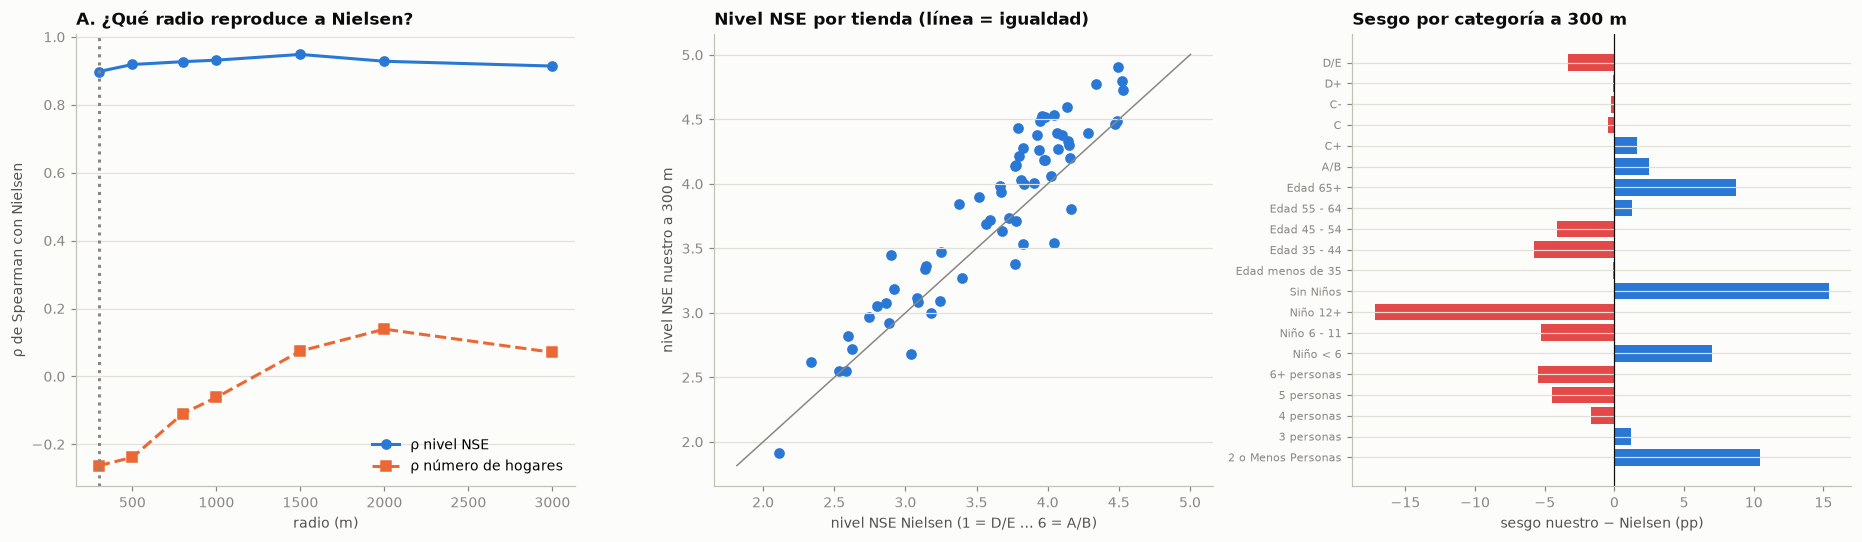

In [6]:
def perfil_categoria(r_):
    s_ = nuestro[r_]
    filas = []
    for g_, cs in GRUPOS.items():
        pg = s_[cs].div(s_[cs].sum(axis=1).replace(0, np.nan), axis=0) * 100
        png_ = zm[[f"{c}|%" for c in cs]].set_axis(cs, axis=1)
        png_ = png_.div(png_.sum(axis=1), axis=0) * 100
        for c in cs:
            filas.append({"grupo": g_, "categoría": c, "radio (m)": r_, "% nuestro (media)": pg[c].mean(), "% Nielsen (media)": png_[c].mean(),
                          "sesgo (pp)": (pg[c] - png_[c]).mean(), "error medio (pp)": (pg[c] - png_[c]).abs().mean(),
                          "ρ entre tiendas": stats.spearmanr(pg[c], png_[c], nan_policy="omit")[0]})
    return pd.DataFrame(filas)


perfil = pd.concat([perfil_categoria(R300), perfil_categoria(R_MEJOR)] if R_MEJOR != R300 else [perfil_categoria(R300)], ignore_index=True)
display(perfil[perfil["radio (m)"].eq(R300)].round(2))

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
ax[0].plot(radios["radio (m)"], radios["ρ nivel NSE (N)"], "o-", label="ρ nivel NSE")
ax[0].plot(radios["radio (m)"], radios["ρ hogares"], "s--", label="ρ número de hogares")
ax[0].axvline(R300, color=eda.MUTED, ls=":")
ax[0].set(xlabel="radio (m)", ylabel="ρ de Spearman con Nielsen", title="A. ¿Qué radio reproduce a Nielsen?")
ax[0].legend()
s300 = nuestro[R300]
p300 = s300[NSE].div(s300[NSE].sum(axis=1), axis=0)
N300 = (p300 * K_NSE).sum(axis=1)
ax[1].scatter(zm.N_n, N300, color=eda.PALETA[0])
lim = [min(zm.N_n.min(), N300.min()) - 0.1, max(zm.N_n.max(), N300.max()) + 0.1]
ax[1].plot(lim, lim, color=eda.MUTED, lw=1)
ax[1].set(xlabel="nivel NSE Nielsen (1 = D/E … 6 = A/B)", ylabel=f"nivel NSE nuestro a {R300} m", title="Nivel NSE por tienda (línea = igualdad)")
pc = perfil[perfil["radio (m)"].eq(R300)]
ax[2].barh(pc["categoría"], pc["sesgo (pp)"], color=[eda.PALETA[0] if v >= 0 else eda.PALETA[7] for v in pc["sesgo (pp)"]])
ax[2].axvline(0, color=eda.TINTA, lw=0.8)
ax[2].set(xlabel="sesgo nuestro − Nielsen (pp)", title=f"Sesgo por categoría a {R300} m")
ax[2].tick_params(axis="y", labelsize=7)
plt.tight_layout(); plt.show()

### A.3 La referencia del índice de Nielsen

**Qué se hace:** de cada tienda se despeja la referencia que Nielsen usó para su índice: ref = % / índice × 100. Si es la misma
en todas las tiendas, es una referencia fija (región o país); se compara con la de la ZM, la de Yucatán y la de nuestros PDV.

**Por qué:** la 1.ª letra es "alto o bajo frente a una referencia". Si Nielsen compara contra la Región Sur y nosotros contra el
subcanal en la ZM, la misma zona puede ser H para uno y L para el otro aunque el perfil coincida.

In [7]:
idx_n = nie[[f"{c}|Indice" for c in NSE]].set_axis(NSE, axis=1)
ref_impl = (pn_all / idx_n.replace(0, np.nan) * 100)
ref_tab = pd.DataFrame({"referencia implícita Nielsen (mediana)": ref_impl.median() * 100,
                        "dispersión entre tiendas (IQR, pp)": (ref_impl.quantile(0.75) - ref_impl.quantile(0.25)) * 100})
ref_zm_hog = hx_cat[NSE].sum() / hx_cat[NSE].sum().sum() * 100
ref_tab["ZM Mérida 2025 (nuestros hogares)"] = ref_zm_hog
ref_tab["autoservicios Nielsen de la ZM (media de sus %)"] = (zm[[f"{c}|%" for c in NSE]].set_axis(NSE, axis=1) * 100).mean()
display(ref_tab.round(2))
N_REF_NIELSEN = float((ref_impl.median() / ref_impl.median().sum() * K_NSE).sum())
REFERENCIA = (f"El índice de Nielsen usa una referencia fija (IQR entre tiendas ≤ {ref_tab['dispersión entre tiendas (IQR, pp)'].max():.2f} pp): "
              + ", ".join(f"{c} {v:.1f}%" for c, v in ref_tab['referencia implícita Nielsen (mediana)'].items())
              + f" (nivel N = {N_REF_NIELSEN:.2f}). Es más baja que la ZM Mérida 2025 (A/B {ref_zm_hog['A/B']:.1f}%, D/E {ref_zm_hog['D/E']:.1f}%): "
              "una referencia regional, no de la ZM.")
print(REFERENCIA)

,referencia implícita Nielsen (mediana),"dispersión entre tiendas (IQR, pp)",ZM Mérida 2025 (nuestros hogares),autoservicios Nielsen de la ZM (media de sus %)
A/B,10.660,0.050,13.350,17.180
C+,14.030,0.070,16.020,19.460
C,15.370,0.080,15.620,18.610
C-,15.930,0.080,15.590,15.370
D+,13.850,0.070,13.870,11.330
D/E,30.160,0.160,25.560,18.040


El índice de Nielsen usa una referencia fija (IQR entre tiendas ≤ 0.16 pp): A/B 10.7%, C+ 14.0%, C 15.4%, C- 15.9%, D+ 13.8%, D/E 30.2% (nivel N = 3.01). Es más baja que la ZM Mérida 2025 (A/B 13.3%, D/E 25.6%): una referencia regional, no de la ZM.


## B. Método: nuestra regla de Letra 1 aplicada en la coordenada del supermercado

**Qué se hace:** primero se reconstruye la regla de Nielsen: en toda la Región Sur se mide qué tan bien separa su nivel NSE (y su
número de hogares) sus H de sus L (AUC) y qué corte reproduce sus letras. Después se aplica **nuestra** Letra 1 en la coordenada
de cada autoservicio de la ZM: el clúster NSE (hexágono H3 res 9 que contiene la tienda + buffer de 300 m desde su centro), su
nivel N INEGI y N* con AltScore (λ = 0.25), y se compara con la 1.ª letra de Nielsen con tres cortes:
(1) **la media de las 65 tiendas** (relativo, como nuestra regla); (2) **la referencia de Nielsen** (N = nivel de su referencia
regional); (3) **la media de nuestros PDV objetivo** (el corte que de verdad usa el 06).

**Por qué:** separa dos preguntas: ¿nuestro NSE **ordena** las zonas como Nielsen? (AUC, sin corte) y ¿nuestro **corte** da la
misma letra? (exactitud y κ con cada corte).

In [8]:
regla_n = pd.DataFrame([{"variable": nombre, "AUC en la Región Sur": roc_auc_score(nie.L1n == "H", nie[col]),
                          "AUC en la ZM Mérida": roc_auc_score(zm.L1n == "H", zm[col])}
                         for nombre, col in [("nivel NSE (N) de Nielsen", "N_n"), ("número de hogares de Nielsen", "HH_n")]])
acc_ref = ((np.where(nie.N_n >= N_REF_NIELSEN, "H", "L")) == nie.L1n).mean()
por_zona = (nie.groupby("Zonas Metropolitanas").agg(tiendas=("L1n", "size"), **{"% H": ("L1n", lambda s: (s == "H").mean() * 100)})
            .query("tiendas >= 30").sort_values("% H"))
display(regla_n.round(3))
display(por_zona.round(1))
REGLA_NIELSEN = (f"La 1.ª letra de Nielsen la decide el NSE (AUC {regla_n.iloc[0]['AUC en la Región Sur']:.3f} en la región), no el número de hogares "
                 f"(AUC {regla_n.iloc[1]['AUC en la Región Sur']:.2f}). Con su referencia regional (N ≥ {N_REF_NIELSEN:.2f}) se reproduce el "
                 f"{acc_ref:.0%} de sus letras; el % de H cambia mucho entre zonas (de {por_zona['% H'].min():.0f}% a {por_zona['% H'].max():.0f}%): "
                 "el corte es regional, no por ZM.")
print(REGLA_NIELSEN)

# clúster NSE de nuestra metodología en la coordenada de cada autoservicio
zm["cl"] = [h3.latlng_to_cell(a, b, RES_CL) for a, b in zip(zm.lat, zm.lon)]
cla, clo = LT.centros(zm.cl)
hh_cl = LT.suma_area(hx_cat[NSE], LT.hexagonos_en_radio(cla, clo, R300, C.H3_RES)).set_axis(NSE, axis=1)
zm["N_k"] = LT.nivel_medio(hh_cl).to_numpy()
zm["hog_k"] = hh_cl.sum(axis=1).to_numpy()
# AltScore con la misma escala que el 06 (cuantiles de los clústeres con PDV objetivo)
zm["N_k_alt"] = zm.N_k
if F_ALT.exists():
    alt = pd.read_parquet(F_ALT)
    loc = A.ubicacion(alt)
    if loc.get("lat") and loc.get("lon") and "indice_nse_altscore" in alt:
        alt = alt.dropna(subset=[loc["lat"], loc["lon"]]).reset_index(drop=True)
        va = alt.indice_nse_altscore.to_numpy(float)
        cer = R.en_radio(cla, clo, alt[loc["lat"]].to_numpy(float), alt[loc["lon"]].to_numpy(float), R300)
        a_k = np.array([np.nanmean(va[i]) if len(i) else np.nan for i in cer])
        n_k = np.array([int(np.isfinite(va[i]).sum()) for i in cer])
        base_cl = let[let.objetivo].drop_duplicates("cluster_nse")
        n_alt = LT.a_escala(pd.Series(np.where(n_k >= MIN_ALT, a_k, np.nan)), base_cl.N_inegi, x_base=base_cl.alt_cluster)
        zm["N_k_alt"] = LT.mover_nse(zm.N_k, n_alt.to_numpy(), LAM).to_numpy()
CORTES = {"media de las 65 tiendas (relativo, como el 06)": zm.N_k.mean(),
          f"referencia regional de Nielsen (N ≥ {N_REF_NIELSEN:.2f})": N_REF_NIELSEN,
          "media de nuestros PDV Tradicional objetivo": float(ob.N_inegi.mean())}
metodo = []
for var, x_ in [("N INEGI", zm.N_k), ("N* INEGI + AltScore", zm.N_k_alt)]:
    auc_ = roc_auc_score(zm.L1n == "H", x_)
    lo_, hi_ = boot(lambda y, x: roc_auc_score(y, x), (zm.L1n == "H").to_numpy(), x_.to_numpy())
    for nombre, t_ in CORTES.items():
        f_ = acuerdo(f"{var} · corte {nombre}", zm.L1n, np.where(x_ >= t_, "H", "L"))
        f_.update({"AUC (sin corte)": auc_, "IC95 AUC": f"[{lo_:.2f}, {hi_:.2f}]", "% H nuestro": (x_ >= t_).mean() * 100,
                   "% H Nielsen": (zm.L1n == "H").mean() * 100})
        metodo.append(f_)
metodo = pd.DataFrame(metodo)
display(metodo.round(3))
fpr, tpr, thr = roc_curve(zm.L1n == "H", zm.N_k)
T_OPT = float(thr[np.argmax(tpr - fpr)])
METODO = (f"Nuestro NSE del clúster ordena las zonas como Nielsen: AUC {metodo.iloc[0]['AUC (sin corte)']:.2f} {metodo.iloc[0]['IC95 AUC']}. "
          f"La letra coincide en {metodo.iloc[0]['exactitud']:.0%} con el corte relativo (κ {metodo.iloc[0]['κ de Cohen']:.2f}), "
          f"{metodo.iloc[1]['exactitud']:.0%} con la referencia de Nielsen y {metodo.iloc[2]['exactitud']:.0%} con el corte de nuestros PDV Tradicional "
          f"(κ {metodo.iloc[2]['κ de Cohen']:.2f}): la diferencia está en el corte, no en el NSE. El corte que mejor separa (Youden) es N ≥ {T_OPT:.2f} "
          f"(dato de 65 tiendas: indicativo, no para fijar la regla).")
print(METODO)

,variable,AUC en la Región Sur,AUC en la ZM Mérida
0,nivel NSE (N) de Nielsen,0.991,1.000
1,número de hogares de Nielsen,0.510,0.366


,tiendas,% H
Zonas Metropolitanas,,
NON-METRO,413,9.900
VERACRUZ,30,30.000
CANCUN,51,45.100
TOLUCA,42,54.800
PUEBLA TLAXCALA,72,59.700
CUERNAVACA,30,60.000
VALLE DE MEXICO,462,68.000
MERIDA,65,69.200
QUERETARO,40,97.500


La 1.ª letra de Nielsen la decide el NSE (AUC 0.991 en la región), no el número de hogares (AUC 0.51). Con su referencia regional (N ≥ 3.01) se reproduce el 95% de sus letras; el % de H cambia mucho entre zonas (de 10% a 98%): el corte es regional, no por ZM.


,comparación,n,exactitud,IC95 exactitud,κ de Cohen,IC95 κ,lectura κ,AUC (sin corte),IC95 AUC,% H nuestro,% H Nielsen
0,N INEGI · corte media de las 65 tiendas (relat...,65,0.877,"[0.80, 0.95]",0.740,"[0.57, 0.89]",bueno,0.989,"[0.96, 1.00]",56.923,69.231
1,N INEGI · corte referencia regional de Nielsen...,65,0.877,"[0.80, 0.95]",0.675,"[0.45, 0.87]",bueno,0.989,"[0.96, 1.00]",81.538,69.231
2,N INEGI · corte media de nuestros PDV Tradicio...,65,0.800,"[0.71, 0.89]",0.427,"[0.20, 0.65]",moderado,0.989,"[0.96, 1.00]",89.231,69.231
3,N* INEGI + AltScore · corte media de las 65 ti...,65,0.862,"[0.77, 0.94]",0.711,"[0.53, 0.87]",bueno,0.990,"[0.97, 1.00]",55.385,69.231
4,N* INEGI + AltScore · corte referencia regiona...,65,0.846,"[0.75, 0.92]",0.581,"[0.34, 0.79]",moderado,0.990,"[0.97, 1.00]",84.615,69.231
5,N* INEGI + AltScore · corte media de nuestros ...,65,0.815,"[0.72, 0.89]",0.480,"[0.24, 0.72]",moderado,0.990,"[0.97, 1.00]",87.692,69.231


Nuestro NSE del clúster ordena las zonas como Nielsen: AUC 0.99 [0.96, 1.00]. La letra coincide en 88% con el corte relativo (κ 0.74), 88% con la referencia de Nielsen y 80% con el corte de nuestros PDV Tradicional (κ 0.43): la diferencia está en el corte, no en el NSE. El corte que mejor separa (Youden) es N ≥ 3.53 (dato de 65 tiendas: indicativo, no para fijar la regla).


## C. Geografía: nuestras tiendas Tradicional alrededor de cada supermercado de Nielsen

**Qué se hace:** como Nielsen es **Moderno** y nosotros **Tradicional**, se compara por zona. Para cada autoservicio de la ZM se
toman nuestros PDV Tradicional objetivo a ≤ 300 m, 500 m y 1 km y se calcula: el % con Letra 1 = H y la letra mayoritaria (vs la
1.ª letra de Nielsen), y lo mismo para la Letra 2 (vs la 2.ª de Nielsen). También a escala de **zona H3 res 7** (≈ 5 km²): letra
mayoritaria de nuestros PDV contra la mayoritaria de los autoservicios Nielsen de la zona.

**Por qué:** la Letra 1 describe la zona (hogares), así que debe coincidir aunque el canal sea otro. La Letra 2 describe la venta
de **cada tienda en su canal**: que un supermercado venda mucho no implica que las tiendas de barrio de al lado vendan mucho
(pueden competir con él). Una coincidencia baja en Letra 2 es esperada y no invalida el método; una baja en Letra 1 sí lo haría.

,comparación,autoservicios con ≥ 3 PDV,mediana de PDV alrededor,exactitud,IC95 exactitud,κ de Cohen,IC95 κ,AUC del % H
0,Letra 1 (NSE) · mayoría de nuestros PDV a ≤ 300 m,35,5.000,0.686,"[0.51, 0.83]",0.382,"[0.16, 0.63]",0.781
1,Letra 2 (venta) · mayoría de nuestros PDV a ≤ ...,35,5.000,0.714,"[0.54, 0.86]",0.205,"[-0.16, 0.55]",0.684
2,Letra 1 (NSE) · mayoría de nuestros PDV a ≤ 500 m,56,11.000,0.750,"[0.62, 0.86]",0.355,"[0.12, 0.59]",0.904
3,Letra 2 (venta) · mayoría de nuestros PDV a ≤ ...,56,11.000,0.786,"[0.68, 0.89]",0.284,"[-0.02, 0.57]",0.704
4,Letra 1 (NSE) · mayoría de nuestros PDV a ≤ 10...,65,43.000,0.769,"[0.66, 0.86]",0.316,"[0.09, 0.55]",0.912
5,Letra 2 (venta) · mayoría de nuestros PDV a ≤ ...,65,43.000,0.754,"[0.65, 0.86]",0.148,"[-0.09, 0.41]",0.656


,comparación,n,exactitud,IC95 exactitud,κ de Cohen,IC95 κ,lectura κ,ρ del % H (zona)
0,Letra 1 · zona H3 r7 (mayoría vs mayoría),34,0.765,"[0.62, 0.91]",0.481,"[0.18, 0.76]",moderado,0.828
1,Letra 2 · zona H3 r7 (mayoría vs mayoría),34,0.824,"[0.71, 0.94]",0.000,"[0.00, 0.00]",pobre,0.381


Por geografía (Moderno de Nielsen vs nuestro Tradicional a ≤ 500 m): la Letra 1 coincide en 75% (κ 0.36, 56 autoservicios con ≥ 3 PDV alrededor); la Letra 2 en 79% (κ 0.28). En 34 zonas H3 r7 con ambos: Letra 1 76%, Letra 2 82%. La Letra 1 viaja entre canales (es la zona); la Letra 2 no tiene por qué (es la venta de cada tienda en su canal).


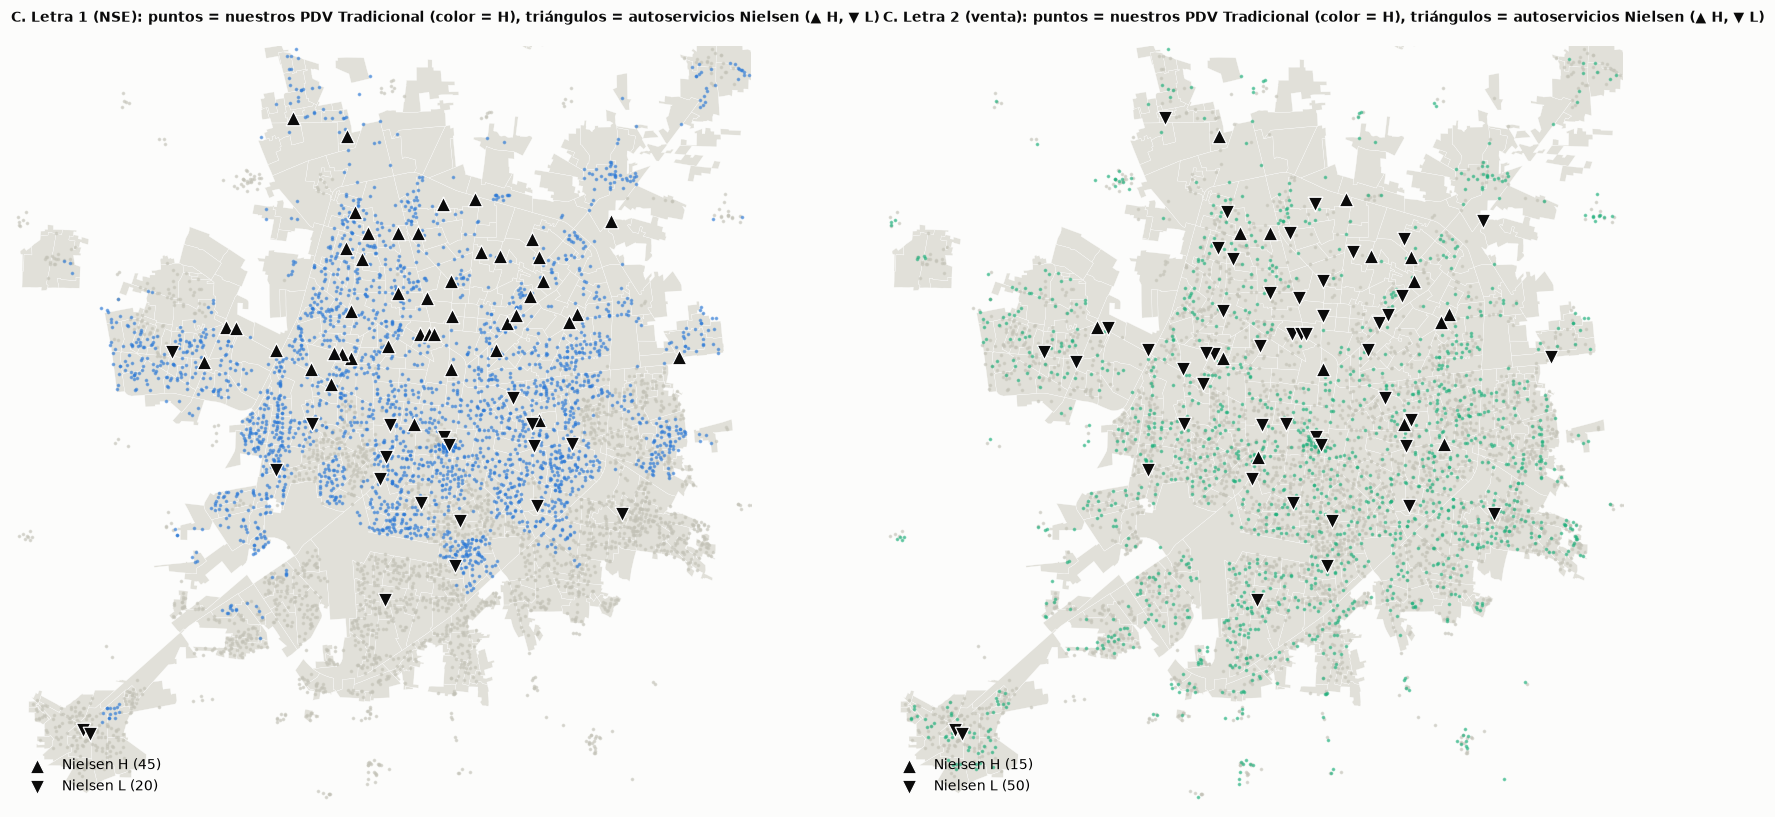

In [9]:
ob_g = ob.dropna(subset=["Latitud", "Longitud"]).reset_index(drop=True)
geo = []
vec_cache = {}
for r_ in (300, 500, 1000):
    v_ = R.en_radio(zm.lat, zm.lon, ob_g.Latitud.to_numpy(float), ob_g.Longitud.to_numpy(float), r_)
    vec_cache[r_] = v_
    n_ = np.array([len(x) for x in v_])
    pH1 = np.array([(ob_g.L1.to_numpy()[x] == "H").mean() if len(x) else np.nan for x in v_])
    pH2 = np.array([(ob_g.L2.to_numpy()[x] == "H").mean() if len(x) else np.nan for x in v_])
    ok = n_ >= 3
    for letra_, pH, ref_ in [("Letra 1 (NSE)", pH1, zm.L1n), ("Letra 2 (venta)", pH2, zm.L2n)]:
        may = np.where(pH >= 0.5, "H", "L")
        f_ = acuerdo(f"{letra_} · mayoría de nuestros PDV a ≤ {r_} m", ref_[ok], may[ok])
        f_.update({"radio (m)": r_, "letra": letra_, "autoservicios con ≥ 3 PDV": int(ok.sum()),
                   "mediana de PDV alrededor": float(np.median(n_[ok])) if ok.any() else np.nan,
                   "AUC del % H": roc_auc_score(ref_[ok] == "H", pH[ok]) if ok.sum() > 5 and ref_[ok].nunique() > 1 else np.nan})
        geo.append(f_)
        zm[f"pH_{letra_[6]}_{r_}"] = pH
    zm[f"n_pdv_{r_}"] = n_
geo = pd.DataFrame(geo)
display(geo[["comparación", "autoservicios con ≥ 3 PDV", "mediana de PDV alrededor", "exactitud", "IC95 exactitud", "κ de Cohen", "IC95 κ", "AUC del % H"]].round(3))

# zonas H3 res 7: mayoría contra mayoría
zm["z7"] = [h3.latlng_to_cell(a, b, 7) for a, b in zip(zm.lat, zm.lon)]
ob_g["z7"] = [h3.latlng_to_cell(a, b, 7) for a, b in zip(ob_g.Latitud, ob_g.Longitud)]
zn = zm.groupby("z7").agg(autoservicios=("L1n", "size"), L1n_H=("L1n", lambda s: (s == "H").mean()), L2n_H=("L2n", lambda s: (s == "H").mean()))
zo = ob_g.groupby("z7").agg(pdv=("L1", "size"), L1_H=("L1", lambda s: (s == "H").mean()), L2_H=("L2", lambda s: (s == "H").mean()))
zz = zn.join(zo, how="inner").query("pdv >= 5")
zonas = pd.DataFrame([acuerdo("Letra 1 · zona H3 r7 (mayoría vs mayoría)", np.where(zz.L1n_H >= 0.5, "H", "L"), np.where(zz.L1_H >= 0.5, "H", "L")),
                      acuerdo("Letra 2 · zona H3 r7 (mayoría vs mayoría)", np.where(zz.L2n_H >= 0.5, "H", "L"), np.where(zz.L2_H >= 0.5, "H", "L"))])
zonas["ρ del % H (zona)"] = [stats.spearmanr(zz.L1n_H, zz.L1_H)[0], stats.spearmanr(zz.L2n_H, zz.L2_H)[0]]
display(zonas.round(3))
g1 = geo[geo.letra.eq("Letra 1 (NSE)") & geo["radio (m)"].eq(500)].iloc[0]
g2 = geo[geo.letra.eq("Letra 2 (venta)") & geo["radio (m)"].eq(500)].iloc[0]
GEOGRAFIA = (f"Por geografía (Moderno de Nielsen vs nuestro Tradicional a ≤ 500 m): la Letra 1 coincide en {g1['exactitud']:.0%} "
             f"(κ {g1['κ de Cohen']:.2f}, {g1['autoservicios con ≥ 3 PDV']} autoservicios con ≥ 3 PDV alrededor); la Letra 2 en {g2['exactitud']:.0%} "
             f"(κ {g2['κ de Cohen']:.2f}). En {len(zz)} zonas H3 r7 con ambos: Letra 1 {zonas.iloc[0]['exactitud']:.0%}, Letra 2 {zonas.iloc[1]['exactitud']:.0%}. "
             "La Letra 1 viaja entre canales (es la zona); la Letra 2 no tiene por qué (es la venta de cada tienda en su canal).")
print(GEOGRAFIA)

fig, ax = plt.subplots(1, 2, figsize=(16, 7.5))
pts_ob = gpd.GeoDataFrame(ob_g, geometry=gpd.points_from_xy(ob_g.Longitud, ob_g.Latitud), crs=4326).to_crs(ageb.crs)
pts_n = gpd.GeoDataFrame(zm, geometry=gpd.points_from_xy(zm.lon, zm.lat), crs=4326).to_crs(ageb.crs)
for a_, col, ref_, tit in [(ax[0], "L1", "L1n", "Letra 1 (NSE)"), (ax[1], "L2", "L2n", "Letra 2 (venta)")]:
    ageb.plot(ax=a_, color=eda.GRID, edgecolor="white", lw=0.2)
    for l_, c_ in [("L", "#c3c2b7"), ("H", MP.COLOR_L1["H"] if col == "L1" else MP.COLOR_L2["H"])]:
        pts_ob[pts_ob[col] == l_].plot(ax=a_, color=c_, markersize=2, alpha=0.5)
    for l_, mk in [("H", "^"), ("L", "v")]:
        sub = pts_n[pts_n[ref_] == l_]
        sub.plot(ax=a_, color=eda.TINTA, marker=mk, markersize=90, edgecolor="white", lw=0.8, label=f"Nielsen {l_} ({len(sub)})")
    x0, y0, x1, y1 = pts_n.total_bounds
    a_.set_xlim(x0 - 2500, x1 + 2500); a_.set_ylim(y0 - 2500, y1 + 2500)
    a_.set_axis_off(); a_.legend(loc="lower left")
    a_.set_title(f"C. {tit}: puntos = nuestros PDV Tradicional (color = H), triángulos = autoservicios Nielsen (▲ H, ▼ L)", fontsize=9)
plt.tight_layout(); plt.show()

## D. ¿Rappi anticipa la 2.ª letra de Nielsen?

**Qué se hace:** Rappi sí observa supermercados. Se empata cada autoservicio de Nielsen con la tienda física Rappi **de su misma
cadena** a ≤ 200 m (Chedraui ↔ Chedraui, Walmart ↔ Walmart, San Francisco de Asís ↔ Súper Akí, …) y se mide si sus pedidos/mes
separan las H de las L de la 2.ª letra de Nielsen (AUC y δ de Cliff). **Solo sueros Coca-Cola** (`Product_Maker_Standard` =
COCA-COLA y subcategoría sueros: Flashlyte; Powerade es isotónico y queda fuera, guiado por el CP); el total de sueros e isotónicos (con competidores) va como comparación.
Antes, la **tabla temporal** de los productos Coca-Cola que se toman: pedidos y unidades por mes y producto.

**Por qué:** en nuestra Letra 2 Rappi pesa 1 de 5. Si Rappi anticipa la venta medida por Nielsen en el mismo establecimiento,
es una señal de demanda que vale la pena; si no, su peso debería bajar. (Ventanas distintas: Nielsen FY'23, Rappi 2025-2026.)

In [10]:
CADENA_RAPPI = {"CHEDRAUI": "chedraui", "WAL-MART": "walmart|wm ", "WALMART EXPRESS": "walmart|superama", "SORIANA": "soriana",
                "SUPER SAN FCO DE ASIS": "aki|akí|san francisco", "BODEGA AURRERA": "aurrera", "MI BODEGA": "aurrera|mi bodega"}


def patron(cadena):
    for k_, v_ in CADENA_RAPPI.items():
        if str(cadena).upper().startswith(k_):
            return v_
    return None


lin = pd.read_parquet(C.PROC / f"rappi_hidratacion_lineas_{C.SLUG}.parquet")
lin_cc = lin[lin.Product_Maker_Standard.eq(C.RAPPI_FABRICANTE) & lin.subcategoria.isin(C.RAPPI_SUBCATEGORIAS_L2)].copy()   # sueros Coca-Cola (Flashlyte), como la Letra 2
assert lin_cc.Product_Brand.isin(["Flashlyte"]).all(), "aparece otra marca de sueros Coca-Cola: revisar"
lin_cc["producto"] = lin_cc.Product_Brand + " · " + lin_cc.Product_name.fillna("(sin nombre)")
temporal = (lin_cc.groupby(["mes", "Product_Brand", "subcategoria", "producto"])
            .agg(pedidos=("order_code", "nunique"), unidades=("beverage_units", "sum"), tiendas=("tienda_fisica", "nunique"))
            .reset_index().sort_values(["mes", "pedidos"], ascending=[True, False]))
temporal_marca = lin_cc.pivot_table(index="mes", columns="Product_Brand", values="order_code", aggfunc="nunique", fill_value=0)
temporal_marca["Coca-Cola total"] = lin_cc.groupby("mes").order_code.nunique()
temporal_marca["sueros e isotónicos total (con competidores)"] = lin.groupby("mes").order_code.nunique()
temporal_marca["% pedidos con Coca-Cola"] = temporal_marca["Coca-Cola total"] / temporal_marca["sueros e isotónicos total (con competidores)"] * 100
productos = (lin_cc.groupby(["Product_Brand", "subcategoria", "producto"]).agg(pedidos=("order_code", "nunique"), unidades=("beverage_units", "sum"),
             meses=("mes", "nunique"), primer_mes=("mes", "min"), ultimo_mes=("mes", "max")).reset_index().sort_values("pedidos", ascending=False))
print(f"Productos Coca-Cola en Rappi (ZM, {lin.mes.min()} → {lin.mes.max()}): {lin_cc.producto.nunique()} productos de "
      f"{lin_cc.Product_Brand.nunique()} marcas (" + ", ".join(f"{k} {v:,} líneas" for k, v in lin_cc.Product_Brand.value_counts().items()) +
      f"); {len(lin_cc):,} de {len(lin):,} líneas ({len(lin_cc) / len(lin):.0%}).")
display(temporal_marca.round(1))
display(productos)
ped_cc = lin_cc.groupby("tienda_fisica").order_code.nunique()          # pedidos con Coca-Cola por tienda física
rp["pedidos_cc"] = rp.tienda_fisica.map(ped_cc).fillna(0)
rp["pedidos_cc_mes"] = rp.pedidos_cc / rp.meses_vida                    # mismo denominador que el 00c: meses de vida de la tienda
vr_ = R.en_radio(zm.lat, zm.lon, rp.lat, rp.lon, 200)
emp = []
for i_, x_ in enumerate(vr_):
    pat = patron(zm.loc[i_, "Cadena de Autoservicios"])
    cand = [k for k in x_ if pat and pd.Series([rp.nombre.iloc[k]]).str.contains(pat, case=False, regex=True).iloc[0]]
    if cand:
        k = max(cand, key=lambda k: rp.pedidos_cc_mes.iloc[k])
        emp.append({"Nielsen ID": zm.loc[i_, "Nielsen ID"], "tienda Nielsen": zm.loc[i_, "Store Name"], "clúster Nielsen": zm.loc[i_, "cluster_n"],
                    "L2 Nielsen": zm.loc[i_, "L2n"], "tienda Rappi": rp.nombre.iloc[k], "pedidos/mes Coca-Cola": rp.pedidos_cc_mes.iloc[k],
                    "pedidos/mes total (con competidores)": rp.pedidos_mes.iloc[k], "Rappi activa": bool(rp.activa.iloc[k])})
emp = pd.DataFrame(emp)
display(emp.sort_values("pedidos/mes Coca-Cola", ascending=False))
if len(emp) and emp["L2 Nielsen"].nunique() > 1:
    y_ = (emp["L2 Nielsen"] == "H").to_numpy()
    AUC_R = roc_auc_score(y_, emp["pedidos/mes Coca-Cola"])
    lo_r, hi_r = boot(lambda y, x: roc_auc_score(y, x), y_, emp["pedidos/mes Coca-Cola"].to_numpy())
    d_r = eda.cliff_delta(emp.loc[y_, "pedidos/mes Coca-Cola"], emp.loc[~y_, "pedidos/mes Coca-Cola"])
    AUC_T = roc_auc_score(y_, emp["pedidos/mes total (con competidores)"])
    RAPPI = (f"{len(emp)} autoservicios Nielsen tienen su misma cadena en Rappi a ≤ 200 m. Los pedidos/mes de productos Coca-Cola separan sus H de sus L "
             f"de la 2.ª letra con AUC {AUC_R:.2f} [{lo_r:.2f}, {hi_r:.2f}] (δ de Cliff {d_r:+.2f}; mediana H {emp.loc[y_, 'pedidos/mes Coca-Cola'].median():.1f} "
             f"vs L {emp.loc[~y_, 'pedidos/mes Coca-Cola'].median():.1f}); con el total de sueros e isotónicos (con competidores) AUC {AUC_T:.2f}. " +
             ("Rappi Coca-Cola sí anticipa la venta de Nielsen." if lo_r > 0.5 else "La señal no es concluyente con esta muestra."))
else:
    AUC_R = lo_r = hi_r = np.nan
    RAPPI = "No hay suficientes empates de cadena entre Nielsen y Rappi para medirlo."
print(RAPPI)

Productos Coca-Cola en Rappi (ZM, 2025-01 → 2026-08): 5 productos de 1 marcas (Flashlyte 2,241 líneas); 2,241 de 26,876 líneas (8%).


Product_Brand,Flashlyte,Coca-Cola total,sueros e isotónicos total (con competidores),% pedidos con Coca-Cola
mes,,,,
2025-01,48,48,869,5.500
2025-02,41,41,943,4.300
2025-03,59,59,1126,5.200
2025-04,64,64,1013,6.300
2025-05,126,126,1551,8.100
2025-06,99,99,1333,7.400
2025-07,101,101,1281,7.900
2025-08,101,101,1278,7.900
2025-09,81,81,1092,7.400


,Product_Brand,subcategoria,producto,pedidos,unidades,meses,primer_mes,ultimo_mes
3,Flashlyte,Sueros (hidratantes),Flashlyte · Flashlyte Bebida Regular Fresa,751,"1,297.000",20,2025-01,2026-08
4,Flashlyte,Sueros (hidratantes),Flashlyte · Flashlyte Bebida Regular Sandía,493,880.000,19,2025-01,2026-07
0,Flashlyte,Sueros (hidratantes),Flashlyte · Flashlyte Bebida Hidratante Sabor ...,486,789.000,20,2025-01,2026-08
2,Flashlyte,Sueros (hidratantes),Flashlyte · Flashlyte Bebida Regular Coco Limón,417,716.000,20,2025-01,2026-08
1,Flashlyte,Sueros (hidratantes),Flashlyte · Flashlyte Bebida Hidratante Sandía...,75,113.000,2,2026-07,2026-08


,Nielsen ID,tienda Nielsen,clúster Nielsen,L2 Nielsen,tienda Rappi,pedidos/mes Coca-Cola,pedidos/mes total (con competidores),Rappi activa
3,31050400-0,CHEDRAUI SELECTO MERIDA NORTE - 31050400X0,HH,H,"Chedraui, Merida Norte - 253_Super",4.850,76.200,True
21,31050149-0,SUPER AKI LAS AMERICAS - 31050149X0,HL,L,"Súper Akí, Las Américas",1.650,8.350,True
29,31050359-0,CHEDRAUI MERIDA ITZAES - 31050359X0,LH,H,"Chedraui, Merida Itzaes - 29_Super",1.600,18.300,True
1,31050057-0,CHEDRAUI MERIDA CAUCEL - 31050057X0,HH,H,"Chedraui, Merida Caucel - 135_Super",1.400,13.150,True
2,31050461-0,CHEDRAUI MERIDA POLIGONO - 31050461X0,HH,H,"Chedraui, Merida Poligono - 93_Super",1.150,27.700,True
0,440192-0,CHEDRAUI MERIDA AMERICAS - 440192X0,HH,H,"Chedraui, Merida Americas - 43_Super",0.850,14.550,True
35,20240116000205-0,CHEDRAUIÃ¿Â MERIDA CAUCEL NORTE 11-23 - 202401...,LL,L,"Chedraui, Mérida Caucel Norte - 842_Super",0.750,13.200,True
16,31050339-0,SORIANA MEGA MEGA GRAN PLAZA MERIDA - 31050339X0,HL,L,"Soriana Híper, Gran Plaza Merida - 912_Super",0.750,10.950,True
7,9017181-0,SAN FCO AKI SAN PEDRO - 9017181X0,HL,L,"Súper Akí, San Pedro",0.600,3.350,True
4,31050138-0,SORIANA HIPERMERCADO ALTABRISA - 31050138X0,HH,H,"Soriana Híper, Altabrisa - 523_Super",0.600,12.050,True


39 autoservicios Nielsen tienen su misma cadena en Rappi a ≤ 200 m. Los pedidos/mes de productos Coca-Cola separan sus H de sus L de la 2.ª letra con AUC 0.81 [0.60, 0.98] (δ de Cliff +0.62; mediana H 0.8 vs L 0.1); con el total de sueros e isotónicos (con competidores) AUC 0.88. Rappi Coca-Cola sí anticipa la venta de Nielsen.


## F. Exactitud final (clúster de 4) y por partes

**Qué se hace:** se arma nuestro clúster en la zona de cada autoservicio = Letra 1 (nuestro NSE en su coordenada) + Letra 2, y se
compara con el clúster de Nielsen (HH/HL/LH/LL). La Letra 2 tiene dos versiones, porque nuestra venta es de otro canal:
(1) **geografía**: mayoría de nuestros PDV Tradicional a ≤ 500 m (≥ 1 PDV); (2) **Rappi**: pedidos/mes de la tienda Rappi de su
misma cadena, H en el mismo % de tiendas que Nielsen marca H (usa esa proporción: es optimista). Línea de azar = Σ p², con las
proporciones de Nielsen.

**Por qué:** responde la pregunta directa "¿cuánto le atinamos?" por letra y en el clúster completo, con la referencia de azar.

In [11]:
L2_geo = pd.Series(np.where(zm["pH_2_500"] >= 0.5, "H", "L"), index=zm.index).where(zm["pH_2_500"].notna())
L1_geo = pd.Series(np.where(zm["pH_1_500"] >= 0.5, "H", "L"), index=zm.index).where(zm["pH_1_500"].notna())
rp_cad = zm["Nielsen ID"].map(emp.set_index("Nielsen ID")["pedidos/mes Coca-Cola"]) if len(emp) else pd.Series(np.nan, index=zm.index)
corte_rp = rp_cad.quantile(1 - (zm.L2n == "H").mean()) if rp_cad.notna().any() else np.nan
L2_rp = pd.Series(np.where(rp_cad >= corte_rp, "H", "L"), index=zm.index).where(rp_cad.notna())
L1_rel = pd.Series(np.where(zm.N_k >= CORTES["media de las 65 tiendas (relativo, como el 06)"], "H", "L"), index=zm.index)
L1_06 = pd.Series(np.where(zm.N_k >= CORTES["media de nuestros PDV Tradicional objetivo"], "H", "L"), index=zm.index)


def fila_final(nombre, ref, pred):
    m = ref.notna() & pred.notna()
    return acuerdo(nombre, ref[m], pred[m])


final = pd.DataFrame([
    fila_final("Letra 1 · corte relativo", zm.L1n, L1_rel),
    fila_final("Letra 1 · corte de nuestros PDV (el del 06)", zm.L1n, L1_06),
    fila_final("Letra 1 · geografía (mayoría de nuestros PDV a 500 m)", zm.L1n, L1_geo),
    fila_final("Letra 2 · geografía (mayoría de nuestros PDV a 500 m)", zm.L2n, L2_geo),
    fila_final("Letra 2 · Rappi Coca-Cola de la misma cadena", zm.L2n, L2_rp),
    fila_final("Clúster · L1 y L2 geografía (mayoría de nuestros PDV a 500 m)", zm.cluster_n, (L1_geo + L2_geo).where(L1_geo.notna() & L2_geo.notna())),
    fila_final("Clúster · L1 relativo + L2 geografía", zm.cluster_n, (L1_rel + L2_geo).where(L2_geo.notna())),
    fila_final("Clúster · L1 relativo + L2 Rappi", zm.cluster_n, (L1_rel + L2_rp).where(L2_rp.notna())),
    fila_final("Clúster · L1 corte 06 + L2 geografía", zm.cluster_n, (L1_06 + L2_geo).where(L2_geo.notna())),
    fila_final("Clúster · L1 corte 06 + L2 Rappi", zm.cluster_n, (L1_06 + L2_rp).where(L2_rp.notna())),
])
AZAR4 = float((zm.cluster_n.value_counts(normalize=True) ** 2).sum())
AZAR2 = {k: float((zm[k].value_counts(normalize=True) ** 2).sum()) for k in ("L1n", "L2n")}
final["azar"] = [AZAR2["L1n"]] * 3 + [AZAR2["L2n"]] * 2 + [AZAR4] * 5
display(final.round(3))
fi = final.set_index("comparación")
FINAL = (f"Tiendas alrededor (nuestros PDV a 500 m): Letra 1 {fi.loc['Letra 1 · geografía (mayoría de nuestros PDV a 500 m)', 'exactitud']:.0%}, "
         f"Letra 2 {fi.loc['Letra 2 · geografía (mayoría de nuestros PDV a 500 m)', 'exactitud']:.0%}, las dos "
         f"{fi.loc['Clúster · L1 y L2 geografía (mayoría de nuestros PDV a 500 m)', 'exactitud']:.0%} (azar {AZAR4:.0%}).")
print(FINAL)

,comparación,n,exactitud,IC95 exactitud,κ de Cohen,IC95 κ,lectura κ,azar
0,Letra 1 · corte relativo,65,0.877,"[0.80, 0.95]",0.740,"[0.57, 0.89]",bueno,0.574
1,Letra 1 · corte de nuestros PDV (el del 06),65,0.800,"[0.69, 0.89]",0.427,"[0.18, 0.66]",moderado,0.574
2,Letra 1 · geografía (mayoría de nuestros PDV a...,63,0.778,"[0.67, 0.87]",0.369,"[0.13, 0.60]",regular,0.574
3,Letra 2 · geografía (mayoría de nuestros PDV a...,63,0.746,"[0.63, 0.86]",0.226,"[-0.06, 0.50]",regular,0.645
4,Letra 2 · Rappi Coca-Cola de la misma cadena,39,0.821,"[0.69, 0.92]",0.513,"[0.13, 0.79]",moderado,0.645
5,Clúster · L1 y L2 geografía (mayoría de nuestr...,63,0.571,"[0.44, 0.70]",0.259,"[0.07, 0.45]",regular,0.362
6,Clúster · L1 relativo + L2 geografía,63,0.651,"[0.52, 0.78]",0.472,"[0.30, 0.64]",moderado,0.362
7,Clúster · L1 relativo + L2 Rappi,39,0.692,"[0.54, 0.82]",0.526,"[0.31, 0.74]",moderado,0.362
8,Clúster · L1 corte 06 + L2 geografía,63,0.587,"[0.46, 0.70]",0.291,"[0.09, 0.49]",regular,0.362
9,Clúster · L1 corte 06 + L2 Rappi,39,0.667,"[0.51, 0.82]",0.397,"[0.15, 0.63]",regular,0.362


Tiendas alrededor (nuestros PDV a 500 m): Letra 1 78%, Letra 2 75%, las dos 57% (azar 36%).


## E. Tarjeta de resultados: ¿qué tan cerca estamos?

**Qué se hace:** una fila por pregunta con su métrica, su IC y una lectura. Se guarda en `qa/salidas/` (Excel con todas las
tablas y la comparación tienda por tienda).

**Límites (leer antes de concluir):** (1) n = 65 autoservicios: IC anchos; (2) Nielsen es Moderno y FY'23; nosotros Tradicional,
hogares 2025 y ventas 2024-2026; (3) Nielsen no publica su área ni su base de hogares: comparamos perfiles, no conteos; (4) la 2.ª
letra de Nielsen es venta escaneada del supermercado: no hay forma de validar nuestra Letra 2 (venta Bepensa en Tradicional) tienda
por tienda con este archivo.

In [12]:
r300 = radios.set_index("radio (m)").loc[R300]
m_rel, m_ref, m_cp = metodo.iloc[0], metodo.iloc[1], metodo.iloc[2]
tarjeta = pd.DataFrame([
    ("A · Insumos", "Perfil NSE en la coordenada (nivel N)", f"ρ = {r300['ρ nivel NSE (N)']:.2f}", f"a {R300} m; mejor radio {R_MEJOR} m (ρ {radios['ρ nivel NSE (N)'].max():.2f})",
     "cerca" if r300["ρ nivel NSE (N)"] >= 0.8 else "lejos"),
    ("A · Insumos", "Error del perfil NSE por nivel", f"{r300['error medio NSE AMAI (pp)']:.1f} pp", "error absoluto medio por nivel y tienda",
     "cerca" if r300["error medio NSE AMAI (pp)"] <= 3 else "revisar"),
    ("A · Insumos", "Perfil de tamaño, niños y edad del jefe",
     f"{r300['error medio Tamaño del hogar (pp)']:.1f} · {r300['error medio Presencia de niños (pp)']:.1f} · {r300['error medio Edad del jefe (pp)']:.1f} pp",
     "error absoluto medio por categoría", "cerca" if max(r300["error medio Tamaño del hogar (pp)"], r300["error medio Edad del jefe (pp)"]) <= 3 else "revisar"),
    ("A · Insumos", "Número de hogares", f"ρ ≤ {radios['ρ hogares'].max():.2f}", "Nielsen usa otra área (depende del formato)", "no comparable"),
    ("B · Método", "Nuestro NSE ordena las zonas como Nielsen", f"AUC {m_rel['AUC (sin corte)']:.2f}", m_rel["IC95 AUC"], "cerca" if m_rel["AUC (sin corte)"] >= 0.8 else "lejos"),
    ("B · Método", "Letra 1 con corte relativo (como el 06)", f"{m_rel['exactitud']:.0%} · κ {m_rel['κ de Cohen']:.2f}", m_rel["IC95 κ"], m_rel["lectura κ"]),
    ("B · Método", "Letra 1 con la referencia de Nielsen", f"{m_ref['exactitud']:.0%} · κ {m_ref['κ de Cohen']:.2f}", m_ref["IC95 κ"], m_ref["lectura κ"]),
    ("B · Método", "Letra 1 con el corte de nuestros PDV Tradicional", f"{m_cp['exactitud']:.0%} · κ {m_cp['κ de Cohen']:.2f}", m_cp["IC95 κ"], m_cp["lectura κ"]),
    ("C · Geografía", "Letra 1 de nuestros PDV alrededor (500 m)", f"{g1['exactitud']:.0%} · κ {g1['κ de Cohen']:.2f}", g1["IC95 κ"], g1["lectura κ"]),
    ("C · Geografía", "Letra 2 de nuestros PDV alrededor (500 m)", f"{g2['exactitud']:.0%} · κ {g2['κ de Cohen']:.2f}", g2["IC95 κ"], "esperado bajo (otro canal)"),
    ("D · Rappi", "Rappi (solo Coca-Cola) anticipa la 2.ª letra de Nielsen", f"AUC {AUC_R:.2f}" if np.isfinite(AUC_R) else "—",
     f"[{lo_r:.2f}, {hi_r:.2f}] · {len(emp)} tiendas" if np.isfinite(AUC_R) else "", "señal" if np.isfinite(AUC_R) and lo_r > 0.5 else "no concluyente"),
    ("F · Final", "Las dos letras de nuestros PDV a 500 m",
     f"{fi.loc['Clúster · L1 y L2 geografía (mayoría de nuestros PDV a 500 m)', 'exactitud']:.0%}",
     f"{int(fi.loc['Clúster · L1 y L2 geografía (mayoría de nuestros PDV a 500 m)', 'n'])} tiendas · azar {AZAR4:.0%}",
     fi.loc['Clúster · L1 y L2 geografía (mayoría de nuestros PDV a 500 m)', 'lectura κ']),
    ("0 · Interno", "Letras base vs finales (AltScore + Rappi)", f"{interno.iloc[0]['exactitud']:.0%} iguales", "no es exactitud: mismo modelo", "—"),
], columns=["nivel", "pregunta", "resultado", "detalle", "lectura"])
display(tarjeta)

tiendas = zm[["Nielsen ID", "Store Name", "Cadena de Autoservicios", "Municipio", "lat", "lon", "cluster_n", "L1n", "L2n", "N_n", "HH_n",
              "cl", "N_k", "N_k_alt", "hog_k", "HH_ageb", "n_pdv_500", "pH_1_500", "pH_2_500"]].copy()
tiendas["L1 nuestra (corte relativo)"] = np.where(tiendas.N_k >= CORTES["media de las 65 tiendas (relativo, como el 06)"], "H", "L")
tiendas["L1 nuestra (corte PDV Tradicional)"] = np.where(tiendas.N_k >= CORTES["media de nuestros PDV Tradicional objetivo"], "H", "L")
tiendas = tiendas.rename(columns={"cluster_n": "clúster Nielsen", "L1n": "L1 Nielsen", "L2n": "L2 Nielsen", "N_n": "nivel NSE Nielsen",
                                  "HH_n": "hogares Nielsen", "cl": "clúster NSE nuestro (H3 r9)", "N_k": "nivel NSE nuestro (INEGI)",
                                  "N_k_alt": "nivel NSE nuestro (+ AltScore)", "hog_k": "hogares del clúster nuestro", "HH_ageb": "hogares de su AGEB",
                                  "n_pdv_500": "PDV Tradicional a 500 m", "pH_1_500": "% L1 = H de esos PDV", "pH_2_500": "% L2 = H de esos PDV"})

# resultados clave para el resumen ejecutivo (qa2 los lee de aquí, aunque el Excel esté abierto)
tarjeta.astype(str).to_parquet(OUT / "qa1_tarjeta.parquet", index=False)
final.astype({"lectura κ": str}).to_parquet(OUT / "qa1_exactitud_final.parquet", index=False)
pd.DataFrame({"clave": ["COBERTURA", "HOGARES", "REFERENCIA", "REGLA_NIELSEN", "METODO", "GEOGRAFIA", "RAPPI", "FINAL"],
              "texto": [COBERTURA, HOGARES, REFERENCIA, REGLA_NIELSEN, METODO, GEOGRAFIA, RAPPI, FINAL]}).to_parquet(OUT / "qa1_textos.parquet", index=False)

import excel_kin as X
wb = X.libro()
X.hoja_tabla(wb, "Tarjeta", tarjeta, titulo="¿Qué tan cerca está nuestra metodología de la línea base de Nielsen?", ajustar=True,
             nota="Nielsen Golden Stores Sueros FY'23 · Autoservicios (Moderno) · ZM Mérida vs letras del 06 (Tradicional).",
             anchos={"nivel": 16, "pregunta": 46, "resultado": 26, "detalle": 46, "lectura": 22})
X.hoja_tabla(wb, "Radios", radios.round(3), titulo="A · Perfil de hogares por radio en la coordenada de cada autoservicio", nota=HOGARES)
X.hoja_tabla(wb, "Perfil por categoría", perfil.round(2), titulo="A.2 · Sesgo y error por categoría", anchos={"categoría": 22, "grupo": 20})
X.hoja_tabla(wb, "Referencia del índice", ref_tab.round(2).reset_index().rename(columns={"index": "nivel"}), titulo="A.3 · Referencia implícita del índice de Nielsen", nota=REFERENCIA)
X.hoja_tabla(wb, "Letra 1 (método)", metodo.round(3), titulo="B · Nuestra Letra 1 en la coordenada del autoservicio", nota=METODO, anchos={"comparación": 70})
X.hoja_tabla(wb, "Geografía", pd.concat([geo, zonas], ignore_index=True).round(3), titulo="C · Nuestras tiendas Tradicional alrededor de cada autoservicio",
             nota=GEOGRAFIA, anchos={"comparación": 60})
if len(emp):
    X.hoja_tabla(wb, "Rappi vs Nielsen", emp.round(2), titulo="D · Pedidos Rappi de la misma cadena vs 2.ª letra de Nielsen", nota=RAPPI,
                 anchos={"tienda Nielsen": 50, "tienda Rappi": 44})
X.hoja_tabla(wb, "Rappi Coca-Cola por mes", temporal_marca.round(1).reset_index(), titulo="Pedidos con productos Coca-Cola en Rappi por mes (ZM)",
             nota="Coca-Cola = Product_Maker_Standard COCA-COLA (Powerade y Flashlyte). Pedidos únicos con al menos un producto de la marca.")
X.hoja_tabla(wb, "Rappi CC mes x producto", temporal, titulo="Pedidos y unidades por mes y producto Coca-Cola", anchos={"producto": 60})
X.hoja_tabla(wb, "Rappi productos CC", productos, titulo="Productos Coca-Cola que entran al QA", anchos={"producto": 60})
X.hoja_tabla(wb, "Exactitud final", final.round(3), titulo="F · Exactitud del clúster completo y por partes", nota=FINAL, anchos={"comparación": 60})
X.hoja_tabla(wb, "Tiendas", tiendas.round(3), titulo="Comparación tienda por tienda (65 autoservicios de la ZM)", anchos={"Store Name": 50})
X.hoja_tabla(wb, "Consistencia interna", interno.round(3), titulo="0b · Cuánto mueven AltScore y Rappi nuestras letras (no es exactitud)")
X.hoja_tabla(wb, "Fuentes", fuentes_qa, titulo="Archivos usados en el QA", anchos={"archivo": 70, "sha256": 70})
X.portada(wb, "QA contra la línea base de Nielsen", f"Golden Stores Sueros FY'23 (Autoservicios) vs letras del 06 · {C.ZM_NOMBRE}",
          [("Cobertura", COBERTURA), ("Insumos", HOGARES), ("Referencia", REFERENCIA), ("Regla de Nielsen", REGLA_NIELSEN),
           ("Método", METODO), ("Geografía", GEOGRAFIA), ("Rappi", RAPPI), ("Exactitud final", FINAL), ("Elaboró", "Kin Analytics · qa/_src/qa_linea_base_nielsen.py")],
          [("Tarjeta", "Resumen: qué tan cerca estamos."), ("Radios", "Perfil de hogares por radio."), ("Perfil por categoría", "Sesgo por categoría."),
           ("Referencia del índice", "Base del índice de Nielsen."), ("Letra 1 (método)", "Nuestra Letra 1 en su coordenada."),
           ("Geografía", "Nuestros PDV alrededor de cada autoservicio."), ("Rappi vs Nielsen", "Rappi Coca-Cola como señal de venta."), ("Rappi Coca-Cola por mes", "Tabla temporal de productos."),
           ("Exactitud final", "Clúster de 4 y por partes."), ("Tiendas", "Una fila por autoservicio."), ("Consistencia interna", "Base vs final."), ("Fuentes", "Huella de cada archivo.")])
XLSX = OUT / f"qa_linea_base_nielsen_{C.CLIENTE}_{C.SLUG}.xlsx"
try:
    wb.save(XLSX)
except PermissionError:                                    # el Excel está abierto: se guarda aparte y se avisa
    XLSX = XLSX.with_name(XLSX.stem + "_nuevo.xlsx")
    wb.save(XLSX)
    print("AVISO: el Excel anterior está abierto; esta versión quedó en otro archivo.")
print("Guardado:", XLSX.relative_to(BASE))

,nivel,pregunta,resultado,detalle,lectura
0,A · Insumos,Perfil NSE en la coordenada (nivel N),ρ = 0.90,a 300 m; mejor radio 1500 m (ρ 0.95),cerca
1,A · Insumos,Error del perfil NSE por nivel,2.9 pp,error absoluto medio por nivel y tienda,cerca
2,A · Insumos,"Perfil de tamaño, niños y edad del jefe",5.0 · 11.4 · 6.3 pp,error absoluto medio por categoría,revisar
3,A · Insumos,Número de hogares,ρ ≤ 0.14,Nielsen usa otra área (depende del formato),no comparable
4,B · Método,Nuestro NSE ordena las zonas como Nielsen,AUC 0.99,"[0.96, 1.00]",cerca
5,B · Método,Letra 1 con corte relativo (como el 06),88% · κ 0.74,"[0.57, 0.89]",bueno
6,B · Método,Letra 1 con la referencia de Nielsen,88% · κ 0.68,"[0.45, 0.87]",bueno
7,B · Método,Letra 1 con el corte de nuestros PDV Tradicional,80% · κ 0.43,"[0.20, 0.65]",moderado
8,C · Geografía,Letra 1 de nuestros PDV alrededor (500 m),75% · κ 0.36,"[0.12, 0.59]",regular
9,C · Geografía,Letra 2 de nuestros PDV alrededor (500 m),79% · κ 0.28,"[-0.02, 0.57]",esperado bajo (otro canal)


Guardado: qa\salidas\qa_linea_base_nielsen_bepensa_zm_merida.xlsx
